<a href="https://colab.research.google.com/github/rpaivadias69/MALE_Abgaben_PVA-s_Nachbearbeitungen/blob/PVA3_RaulPaivaDias_Nachbearbeitung/MALE_PVA3_Nachbereitungsaufgaben_RaulPaivaDias.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Chapter 5, Exerices

1. What is the fundamental idea behind support vector machines?

The fundamental idea of SVMs is to find a decision boundary (a hyperplane) that separates different classes while maximizing the margin between them. The margin is the distance between the boundary and the closest data points from each class. By maximizing this margin, the model tends to generalize better to new, unseen data instead of just fitting the training set.

2. What is a support vector?

Support vectors are the training instances that lie closest to the decision boundary. They are the most important points in the dataset because the position of the boundary depends entirely on them. If you removed other points, the boundary would stay the same—but removing support vectors would change it.

3. Why is it important to scale the inputs when using SVMs?

SVMs rely on distances between data points to determine the margin and the decision boundary. If features are on very different scales, features with larger values will dominate the distance calculations. This can lead to a poorly shaped boundary. Scaling the inputs (e.g., standardization) ensures that all features have a similar influence.

4. Can an SVM classifier output a confidence score when it classifies an instance? What about a probability?

Yes, an SVM can output a confidence score using the decision_function(), which measures how far a sample is from the decision boundary. The farther away, the more confident the prediction.
However, SVMs do not naturally provide probabilities. If needed, SVC can estimate probabilities by setting probability=True, which uses an additional method (Platt scaling). This makes training slower but gives outputs similar to probabilities.

5. How can you choose between LinearSVC, SVC, and SGDClassifier?

LinearSVC is a good choice for large datasets when the data is approximately linearly separable. It is fast and memory-efficient.

SVC is more flexible because it supports kernels (like RBF), making it suitable for nonlinear problems. However, it can be slower, especially on large datasets.

SGDClassifier is useful for very large datasets or streaming data, since it uses stochastic gradient descent and can be trained incrementally.

6. Say you’ve trained an SVM classifier with an RBF kernel, but it seems to underfit the training set. Should you increase or decrease γ (gamma)? What about C?

If the model underfits, it means it is too simple and cannot capture the patterns in the data.

Increasing gamma makes the decision boundary more flexible and sensitive to individual data points.
Increasing C reduces regularization, allowing the model to focus more on fitting the training data and penalizing misclassifications more strongly.

7. What does it mean for a model to be ϵ-insensitive?

In SVM regression, being ε-insensitive means that errors smaller than ε are ignored. In other words, as long as predictions fall within a certain margin (the ε-tube), they are not considered mistakes. Only larger deviations outside this margin contribute to the loss function.

8. What is the point of using the kernel trick?

The kernel trick allows SVMs to solve nonlinear problems by implicitly mapping data into a higher-dimensional space where it becomes linearly separable. Instead of actually transforming the data (which would be computationally expensive), the kernel function computes similarities directly. This makes it efficient while still allowing complex decision boundaries.





In [1]:
############# Chapter 5 Exercise 9 #############

#Imports

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC, SVC
from sklearn.linear_model import SGDClassifier


In [2]:
# Load the Iris dataset
iris = load_iris(as_frame=True)

# Select only two features for easy visualization
X = iris.data[["petal length (cm)", "petal width (cm)"]].values
y = iris.target.values

# Keep only Setosa and Versicolor (linearly separable)
setosa_or_versicolor = (y == 0) | (y == 1)

X = X[setosa_or_versicolor]
y = y[setosa_or_versicolor]

# Scale features because SVMs are sensitive to feature magnitude
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Set hyperparameters (chosen so models behave similarly)
C_value = 4
sgd_alpha = 0.02


In [3]:
# Linear SVM using liblinear (fast for linear problems)
linear_svc_model = LinearSVC(
    C=C_value,
    loss="hinge",
    max_iter=10_000,
    random_state=42
)

# SVM with linear kernel (more flexible but slower)
svc_model = SVC(
    kernel="linear",
    C=C_value
)

# SGDClassifier approximates linear SVM using hinge loss
sgd_model = SGDClassifier(
    loss="hinge",
    alpha=sgd_alpha,
    max_iter=10_000,
    tol=1e-4,
    random_state=42
)

# Train all three models on the same scaled dataset
linear_svc_model.fit(X_scaled, y)
svc_model.fit(X_scaled, y)
sgd_model.fit(X_scaled, y)


SGDClassifier(alpha=0.02, max_iter=10000, random_state=42, tol=0.0001)

In [4]:
# Print learned weights and bias terms to compare models
print("LinearSVC coefficients:", linear_svc_model.coef_, linear_svc_model.intercept_)
print("SVC coefficients:", svc_model.coef_, svc_model.intercept_)
print("SGDClassifier coefficients:", sgd_model.coef_, sgd_model.intercept_)


LinearSVC coefficients: [[1.05364854 1.09903804]] [0.28475098]
SVC coefficients: [[1.1203284  1.02625193]] [0.31896852]
SGDClassifier coefficients: [[1.07755564 0.97067956]] [0.2811813]


In [5]:
# Helper function to compute decision boundary line from model parameters
def decision_boundary(model, x_min=-2.5, x_max=2.5):
    w = model.coef_[0]      # weights
    b = model.intercept_[0] # bias

    # Generate points along x-axis
    x0 = np.linspace(x_min, x_max, 200)

    # Solve linear equation: w0*x0 + w1*x1 + b = 0
    x1 = -(w[0] * x0 + b) / w[1]

    # Convert back to original feature space
    points_scaled = np.c_[x0, x1]
    return scaler.inverse_transform(points_scaled)

# Compute decision boundaries for each model
linear_svc_boundary = decision_boundary(linear_svc_model)
svc_boundary = decision_boundary(svc_model)
sgd_boundary = decision_boundary(sgd_model)


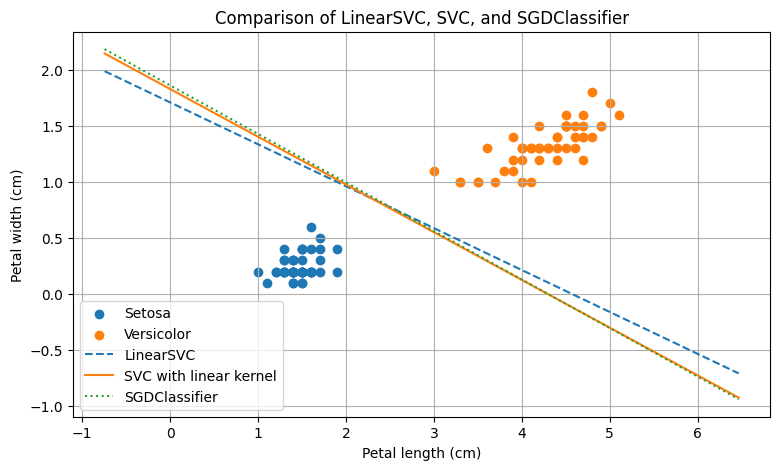

In [11]:
# Plot original data points
plt.figure(figsize=(9, 5))

plt.scatter(X[y == 0, 0], X[y == 0, 1], label="Setosa")
plt.scatter(X[y == 1, 0], X[y == 1, 1], label="Versicolor")

# Plot decision boundaries of each model
plt.plot(linear_svc_boundary[:, 0], linear_svc_boundary[:, 1],
         linestyle="--", label="LinearSVC")

plt.plot(svc_boundary[:, 0], svc_boundary[:, 1],
         linestyle="-", label="SVC with linear kernel")

plt.plot(sgd_boundary[:, 0], sgd_boundary[:, 1],
         linestyle=":", label="SGDClassifier")

# Labels and styling
plt.xlabel("Petal length (cm)")
plt.ylabel("Petal width (cm)")
plt.title("Comparison of LinearSVC, SVC, and SGDClassifier")
plt.legend()
plt.grid(True)
plt.show()


In [9]:
# Check training accuracy for each model
print("LinearSVC accuracy:", linear_svc_model.score(X_scaled, y))
print("SVC accuracy:", svc_model.score(X_scaled, y))
print("SGDClassifier accuracy:", sgd_model.score(X_scaled, y))


LinearSVC accuracy: 1.0
SVC accuracy: 1.0
SGDClassifier accuracy: 1.0


In [18]:
############# Chapter 5 Exercise 10 #############

# Load wine dataset
from sklearn.datasets import load_wine

wine = load_wine()

X_wine = wine.data
y_wine = wine.target

# Scale features (important for SVM performance)
scaler_wine = StandardScaler()
X_wine_scaled = scaler_wine.fit_transform(X_wine)

In [19]:
# Train SVM classifier
# SVC automatically uses One-vs-Rest for multiclass problems
wine_svm = SVC(kernel="rbf", C=5, gamma="scale", random_state=42)

wine_svm.fit(X_wine_scaled, y_wine)

# Check training accuracy
accuracy = wine_svm.score(X_wine_scaled, y_wine)

print("Training accuracy:", accuracy)

Training accuracy: 1.0


In [20]:
############# Chapter 5 Exercise 11 #############

# Extra tools for regression, splitting data, pipelines and tuning
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error
from scipy.stats import loguniform


In [21]:
# Load the original California housing dataset
housing = fetch_california_housing()

X_housing = housing.data
y_housing = housing.target

# Split into training and test data so we can evaluate the final model fairly
X_train, X_test, y_train, y_test = train_test_split(
    X_housing, y_housing, test_size=0.2, random_state=42
)


In [22]:
# SVMs can be slow on large datasets, so I tune on a smaller random subset
X_train_small = X_train[:2000]
y_train_small = y_train[:2000]

# The pipeline first scales the data, then trains an SVR model
svr_pipeline = make_pipeline(
    StandardScaler(),
    SVR()
)

# Search over different values for C and gamma
# loguniform is useful because good values may differ by orders of magnitude
param_distributions = {
    "svr__kernel": ["rbf"],
    "svr__C": loguniform(1, 1000),
    "svr__gamma": loguniform(0.001, 1),
    "svr__epsilon": loguniform(0.01, 1)
}

random_search = RandomizedSearchCV(
    svr_pipeline,
    param_distributions=param_distributions,
    n_iter=30,
    cv=3,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1
)

# Run the hyperparameter search on the smaller dataset
random_search.fit(X_train_small, y_train_small)


RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('standardscaler',
                                              StandardScaler()),
                                             ('svr', SVR())]),
                   n_iter=30, n_jobs=-1,
                   param_distributions={'svr__C': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7b562c99ebd0>,
                                        'svr__epsilon': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7b562be66210>,
                                        'svr__gamma': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7b5629c72d80>,
                                        'svr__kernel': ['rbf']},
                   random_state=42, scoring='neg_root_mean_squared_error')

In [23]:
# Show the best parameters found during tuning
print("Best parameters:")
print(random_search.best_params_)

print("Best cross-validation RMSE:")
print(-random_search.best_score_)


Best parameters:
{'svr__C': np.float64(8.200518402245827), 'svr__epsilon': np.float64(0.015679933916723017), 'svr__gamma': np.float64(0.11290133559092672), 'svr__kernel': 'rbf'}
Best cross-validation RMSE:
0.5640196528593866


In [24]:
# Take the best model and train it again on the full training set
best_svr_model = random_search.best_estimator_

best_svr_model.fit(X_train, y_train)


Pipeline(steps=[('standardscaler', StandardScaler()),
                ('svr',
                 SVR(C=np.float64(8.200518402245827),
                     epsilon=np.float64(0.015679933916723017),
                     gamma=np.float64(0.11290133559092672)))])

In [26]:
# Predict on the test set
y_pred = best_svr_model.predict(X_test)

# Compute MSE first
mse = mean_squared_error(y_test, y_pred)

# Then take square root manually to get RMSE
test_rmse = np.sqrt(mse)

print("Test RMSE:", test_rmse)


Test RMSE: 0.5742245172316116


In [ ]:
############# Chapter 6 #############

1. What is the approximate depth of a decision tree trained (without restrictions) on a training set with one million instances?

A balanced binary tree has a depth of about log₂(m), where m is the number of instances.
For one million samples:

log2(1,000,000)≈20

So the approximate depth is around 20 levels.

2. Is a node’s Gini impurity generally lower or higher than its parent’s? Is it generally lower/higher, or always lower/higher?

It is generally lower (or equal) than its parent’s impurity, but not necessarily always strictly lower.

The reason is that decision trees split nodes in a way that reduces impurity on average, but one of the child nodes can still have a higher impurity—as long as the overall weighted impurity decreases.

3. If a decision tree is overfitting the training set, is it a good idea to try decreasing max_depth?

Yes, decreasing max_depth is a good idea. A very deep tree can memorize the training data, which leads to overfitting. Limiting the depth forces the model to be simpler and improves generalization.

4. If a decision tree is underfitting the training set, is it a good idea to try scaling the input features?

No, scaling does not help decision trees.

Decision trees are not sensitive to feature scaling, because they split based on thresholds, not distances.
To fix underfitting, you would instead increase model complexity (e.g., increase max_depth or reduce regularization).

5. If it takes one hour to train a decision tree on a training set containing one million instances, roughly how much time will it take to train another decision tree on a training set containing ten million instances? Hint: consider the CART algorithm’s computational complexity.

The training complexity of CART is approximately:

O(n⋅mlogm)

If we increase the number of instances from 1 million to 10 million, the dominant factor is roughly:

10 * log(10m) ca.= 10 * (logm + 1 )

So training will take a bit more than 10 times longer, roughly 10-12 hours.

6. If it takes one hour to train a decision tree on a given training set, roughly how much time will it take if you double the number of features?

Training time grows linearly with the number of features.

So if you double the number of features, the training time will roughly double as well.



In [29]:
############# Chapter 6 Exercise 7 #############

# a) Create a noisy moons dataset with 10,000 samples
from sklearn.datasets import make_moons

X_moons, y_moons = make_moons(
    n_samples=10_000,
    noise=0.4,
    random_state=42
)


In [30]:
# b) Split the dataset into training and test data
from sklearn.model_selection import train_test_split

X_train_moons, X_test_moons, y_train_moons, y_test_moons = train_test_split(
    X_moons,
    y_moons,
    test_size=0.2,
    random_state=42
)


In [31]:
# c) Use GridSearchCV to find good hyperparameters
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

tree_clf = DecisionTreeClassifier(random_state=42)

param_grid = {
    "max_leaf_nodes": [5, 10, 15, 20, 30, 40, 50],
    "max_depth": [None, 5, 10, 15],
    "min_samples_split": [2, 5, 10]
}

grid_search = GridSearchCV(
    tree_clf,
    param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train_moons, y_train_moons)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validation accuracy:", grid_search.best_score_)


Best parameters: {'max_depth': None, 'max_leaf_nodes': 20, 'min_samples_split': 2}
Best cross-validation accuracy: 0.8550001673646759


In [32]:
# d) Evaluate the best model on the test set
best_tree_clf = grid_search.best_estimator_

test_accuracy = best_tree_clf.score(X_test_moons, y_test_moons)

print("Test accuracy:", test_accuracy)

Test accuracy: 0.87


In [33]:
############# Chapter 6 Exercise 8 #############

# a) Create 1,000 small subsets from the training set
from sklearn.model_selection import ShuffleSplit

n_trees = 1000
n_instances = 100

mini_sets = []

shuffle_split = ShuffleSplit(
    n_splits=n_trees,
    train_size=n_instances,
    random_state=42
)

for mini_train_index, _ in shuffle_split.split(X_train_moons):
    X_mini_train = X_train_moons[mini_train_index]
    y_mini_train = y_train_moons[mini_train_index]
    mini_sets.append((X_mini_train, y_mini_train))


In [34]:
# b) Train one decision tree per subset using the best parameters from Exercise 7
from sklearn.base import clone
from sklearn.metrics import accuracy_score

forest = []

for X_mini_train, y_mini_train in mini_sets:
    tree = clone(grid_search.best_estimator_)
    tree.fit(X_mini_train, y_mini_train)
    forest.append(tree)

# Evaluate each small tree on the full test set
tree_scores = []

for tree in forest:
    y_pred_tree = tree.predict(X_test_moons)
    tree_scores.append(accuracy_score(y_test_moons, y_pred_tree))

print("Average accuracy of individual trees:", np.mean(tree_scores))


Average accuracy of individual trees: 0.8012284999999999


In [35]:
# c) Collect predictions from all trees and use majority voting
from scipy.stats import mode

all_predictions = np.empty((n_trees, len(X_test_moons)), dtype=np.uint8)

for tree_index, tree in enumerate(forest):
    all_predictions[tree_index] = tree.predict(X_test_moons)

majority_vote_predictions, _ = mode(all_predictions, axis=0)

majority_vote_predictions = majority_vote_predictions.reshape(-1)


In [36]:
# d) Evaluate majority-vote predictions on the test set
forest_accuracy = accuracy_score(y_test_moons, majority_vote_predictions)

print("Random forest accuracy:", forest_accuracy)


Random forest accuracy: 0.872


In [ ]:
############# Chapter 7 #############

1. If you have trained five different models on the exact same training data, and they all achieve 95% precision, is there any chance that you can combine these models to get better results? If so, how? If not, why?

If you have trained five different models on the exact same training data, and they all achieve 95% precision, is there any chance that you can combine these models to get better results? If so, how? If not, why?

2. What is the difference between hard and soft voting classifiers?

A hard voting classifier predicts the class that gets the most votes from all models. A soft voting classifier averages the predicted class probabilities and selects the class with the highest average probability. Soft voting usually performs better because it takes into account the confidence of each model.

3. Is it possible to speed up training of a bagging ensemble by distributing it across multiple servers? What about pasting ensembles, boosting ensembles, random forests, or stacking ensembles?

Yes, bagging and pasting ensembles can be trained in parallel across multiple servers because each model is trained independently. Random forests can also be parallelized for the same reason. Boosting ensembles cannot be easily parallelized because each model depends on the previous one. Stacking can be partially parallelized: the base models can be trained in parallel, but the final model depends on their predictions.

4. What is the benefit of out-of-bag evaluation?

Out-of-bag evaluation allows you to estimate the model’s performance without needing a separate validation set. Since each tree is trained on a bootstrap sample, some instances are left out and can be used to test the model. This makes efficient use of the data.

5. What makes extra-trees ensembles more random than regular random forests? How can this extra randomness help? Are extra-trees classifiers slower or faster than regular random forests?

Extra-trees are more random because they not only use random subsets of features but also choose split thresholds randomly instead of searching for the best split. This extra randomness helps reduce variance and overfitting. Extra-trees classifiers are generally faster than regular random forests because they do not need to search for optimal split points.

6. If your AdaBoost ensemble underfits the training data, which hyperparameters should you tweak, and how?

If the model underfits, you should increase the number of estimators, increase the learning rate, or use a more complex base estimator. These changes make the model more flexible and allow it to better fit the data.

7. If your gradient boosting ensemble overfits the training set, should you increase or decrease the learning rate?

You should decrease the learning rate. A smaller learning rate makes the model learn more slowly and reduces overfitting. Often, this is combined with increasing the number of estimators.


In [1]:
############# Chapter 7 Exercise 8 #############

# Load MNIST dataset
from sklearn.datasets import fetch_openml
from sklearn.svm import LinearSVC

mnist = fetch_openml("mnist_784", version=1, as_frame=False)

X_mnist = mnist.data
y_mnist = mnist.target.astype(int)

# Split into train (50k), validation (10k), test (10k)
# Edit 2: changed Train to 10k due to amount of time
X_train, X_val, X_test = X_mnist[:10000], X_mnist[50000:60000], X_mnist[60000:]
y_train, y_val, y_test = y_mnist[:10000], y_mnist[50000:60000], y_mnist[60000:]

# Train different classifiers
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.svm import SVC

#Edit 2: added  n_jobs=-1
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
extra_clf = ExtraTreesClassifier(n_estimators=100, random_state=42, n_jobs=-1)
###svm_clf = SVC(gamma="scale", probability=True, random_state=42)

# LinearSVC is much faster than SVC on the full MNIST datase
# Edit 2: max_iter from 3k to 1k
svm_clf = LinearSVC(max_iter=1000, random_state=42)

rf_clf.fit(X_train, y_train)
extra_clf.fit(X_train, y_train)
svm_clf.fit(X_train, y_train)

#Evaluate on Validation Set
from sklearn.metrics import accuracy_score

rf_val_acc = accuracy_score(y_val, rf_clf.predict(X_val))
extra_val_acc = accuracy_score(y_val, extra_clf.predict(X_val))
svm_val_acc = accuracy_score(y_val, svm_clf.predict(X_val))

print("Random Forest accuracy:", rf_val_acc)
print("Extra Trees accuracy:", extra_val_acc)
###print("SVM accuracy:", svm_val_acc)
print("Linear SVM accuracy:", svm_val_acc)

# Edit 1: svm_clf = SVC(gamma="scale", probability=True, random_state=42) took over 30 minutes to run, so I cancelled it. and changed to LinearSVC
# Edit 2: runtime still over 20 minutes, applied changes in code
# "Liblinear failed to converge, increase the number of iterations" - Due to high amount of runtime and therefore reduced iterations, the Linear SVM Model does not perform well


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Random Forest accuracy: 0.9521
Extra Trees accuracy: 0.9598
Linear SVM accuracy: 0.8665


In [2]:
# Combine models using soft voting
from sklearn.ensemble import VotingClassifier

voting_clf = VotingClassifier(
    estimators=[
        ("rf", rf_clf),
        ("extra", extra_clf),
        ("svm", svm_clf)
    ],
    ###voting="soft"  # use probabilities
    voting="hard"
)

voting_clf.fit(X_train, y_train)


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


VotingClassifier(estimators=[('rf',
                              RandomForestClassifier(n_jobs=-1,
                                                     random_state=42)),
                             ('extra',
                              ExtraTreesClassifier(n_jobs=-1, random_state=42)),
                             ('svm', LinearSVC(random_state=42))])

In [3]:
#Evaluate Ensemble on Validation set
ensemble_val_acc = accuracy_score(y_val, voting_clf.predict(X_val))

print("Ensemble validation accuracy:", ensemble_val_acc)


Ensemble validation accuracy: 0.9562


In [4]:
#Final Evaluation
ensemble_test_acc = accuracy_score(y_test, voting_clf.predict(X_test))

print("Ensemble test accuracy:", ensemble_test_acc)

# combining multiple strong models can improve performance by reducing errors through averaging.
# taking into consideration the failing of converginf from linear SVM Model


Ensemble test accuracy: 0.9527


In [6]:
############# Chapter 7 Exercise 9 #############

# Each base classifier predicts the validation set
# These predictions become the new features for the blender

import numpy as np

rf_val_pred = rf_clf.predict(X_val)
extra_val_pred = extra_clf.predict(X_val)
svm_val_pred = svm_clf.predict(X_val)

X_blender_train = np.c_[rf_val_pred, extra_val_pred, svm_val_pred]
y_blender_train = y_val

print(X_blender_train.shape)


(10000, 3)


In [7]:
# Train a blender model on the predictions of the individual classifiers
from sklearn.ensemble import RandomForestClassifier

blender_clf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

blender_clf.fit(X_blender_train, y_blender_train)


RandomForestClassifier(random_state=42)

In [8]:
# Make predictions on the test set using the original classifiers
rf_test_pred = rf_clf.predict(X_test)
extra_test_pred = extra_clf.predict(X_test)
svm_test_pred = svm_clf.predict(X_test)

# Combine these predictions into a new test set for the blender
X_blender_test = np.c_[rf_test_pred, extra_test_pred, svm_test_pred]


In [9]:
# The blender makes the final prediction
blender_test_pred = blender_clf.predict(X_blender_test)

blender_test_acc = accuracy_score(y_test, blender_test_pred)

print("Blending ensemble test accuracy:", blender_test_acc)


Blending ensemble test accuracy: 0.9523


In [10]:
# Compare against the voting classifier from the previous exercise
voting_test_acc = accuracy_score(y_test, voting_clf.predict(X_test))

print("Voting classifier test accuracy:", voting_test_acc)
print("Blending ensemble test accuracy:", blender_test_acc)
print("Difference:", blender_test_acc - voting_test_acc)


Voting classifier test accuracy: 0.9527
Blending ensemble test accuracy: 0.9523
Difference: -0.00039999999999995595


In [11]:
# StackingClassifier does a similar thing automatically
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

stacking_clf = StackingClassifier(
    estimators=[
        ("rf", rf_clf),
        ("extra", extra_clf),
        ("svm", svm_clf)
    ],
    final_estimator=LogisticRegression(max_iter=1000),
    cv=3,
    n_jobs=-1
)

stacking_clf.fit(X_train, y_train)

#Same issue, too little computing power... would need to increase max_iter that I already lowered in exercise above...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


StackingClassifier(cv=3,
                   estimators=[('rf',
                                RandomForestClassifier(n_jobs=-1,
                                                       random_state=42)),
                               ('extra',
                                ExtraTreesClassifier(n_jobs=-1,
                                                     random_state=42)),
                               ('svm', LinearSVC(random_state=42))],
                   final_estimator=LogisticRegression(max_iter=1000),
                   n_jobs=-1)

In [12]:
# Evaluate Stacking
stacking_test_acc = accuracy_score(y_test, stacking_clf.predict(X_test))

print("Stacking classifier test accuracy:", stacking_test_acc)
print("Voting classifier test accuracy:", voting_test_acc)
print("Blending ensemble test accuracy:", blender_test_acc)

Stacking classifier test accuracy: 0.9519
Voting classifier test accuracy: 0.9527
Blending ensemble test accuracy: 0.9523
